In [224]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from brokenaxes import brokenaxes
import re

pd.set_option("display.precision", 8)
sns.set_style("whitegrid")

# Use pre-processed csv
data_table = "../data/preprocessed_data.csv"
df = pd.read_csv(data_table, delimiter=",")

In [225]:
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.spines.left": False,
    "axes.linewidth":   0.8,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "axes.labelsize":   7,
    "axes.titlesize":   8,
    "axes.titleweight": "bold",
    "legend.fontsize":  7,
    "figure.dpi":       150,
})

In [226]:
unique_biomarkers = df['Biomarker name'].nunique()
print(f"Number of unique biomarkers analyzed: {unique_biomarkers}")

Number of unique biomarkers analyzed: 190


In [227]:
# Deduplicated
deduplicated_df = df.dropna(subset=['PubmedID', 'Biomarker name'])
unique_pairs = deduplicated_df.drop_duplicates(['PubmedID', 'Biomarker name'])

biomarker_counts = (
    unique_pairs['Biomarker name']
    .value_counts()
    .sort_values(ascending=False)
)

biomarker_counts.value_counts()

count
1     159
2      19
3       4
6       2
4       2
23      1
15      1
7       1
5       1
Name: count, dtype: int64

In [228]:
pivot_biomarker_studies = pd.pivot_table(
    unique_pairs,
    index="Biomarker name",
    values="PubmedID",
    aggfunc="nunique"
).rename(columns={"PubmedID": "n_studies"})

pivot_biomarker_studies.sort_values(by='n_studies', ascending=False)

,n_studies
Biomarker name,
PD-L1,23
p53,15
TP53,7
EGFR,6
Ki-67,6
...,...
EPHA7,1
ERCC1,1
FADD,1


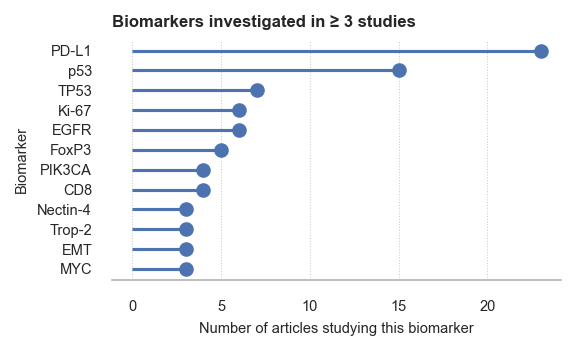

In [329]:
min_num_articles = 3
bio_filtered = biomarker_counts[biomarker_counts >= min_num_articles].copy()
bio_sorted = bio_filtered.sort_values(ascending=True)

plt.figure(figsize=(4, 2.5))
plt.hlines(
    y=bio_sorted.index,
    xmin=0,
    xmax=bio_sorted.values
)
plt.plot(
    bio_sorted.values,
    bio_sorted.index,
    "o"
)

plt.xlabel("Number of articles studying this biomarker")
plt.ylabel("Biomarker")
plt.title(f"Biomarkers investigated in ≥ {min_num_articles} studies", fontweight="bold", loc="left")

ax = plt.gca()
ax.xaxis.grid(True, linestyle=":", linewidth=0.5, color="#cccccc")
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.spines["bottom"].set_color("0.7")
ax.tick_params(axis="both", labelsize=7)

plt.tight_layout()
plt.savefig("figures/biomarker_counts.pdf", bbox_inches="tight")
plt.savefig("figures/biomarker_counts.png", dpi=600, bbox_inches="tight")
plt.show()

In [230]:
unique_publications = deduplicated_df.drop_duplicates(['PubmedID'])
print(f"Number of unique publications analyzed: {unique_publications['PubmedID'].nunique()}")

Number of unique publications analyzed: 107


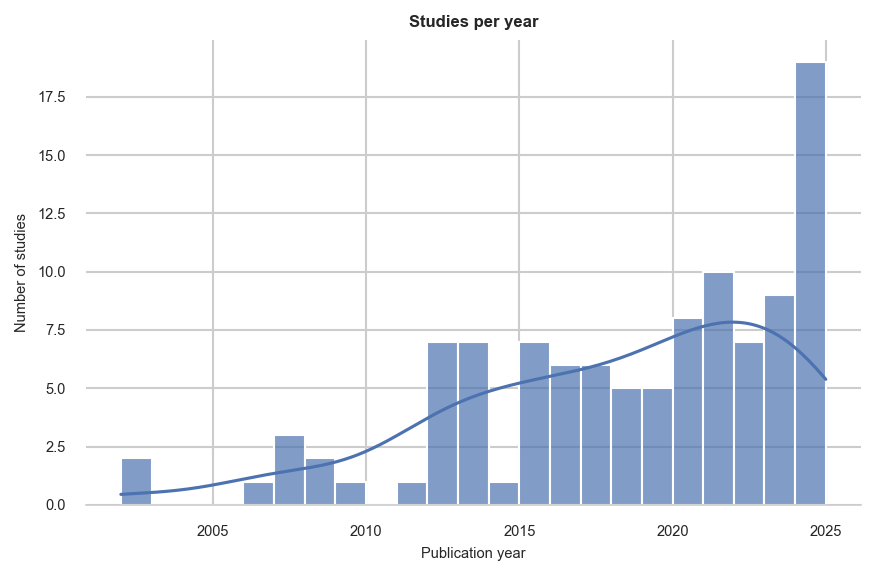

In [231]:
years = unique_publications['Year'].dropna().astype(int)

plt.figure(figsize=(6,4))
sns.histplot(data=years, bins=range(years.min(), years.max()+1), kde=True, alpha=0.7)
plt.ylabel("Number of studies")
plt.xlabel("Publication year")
plt.title("Studies per year", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/year_counts.pdf", bbox_inches="tight")
plt.savefig("figures/year_counts.png", dpi=600, bbox_inches="tight")
plt.show()

Set difference: []


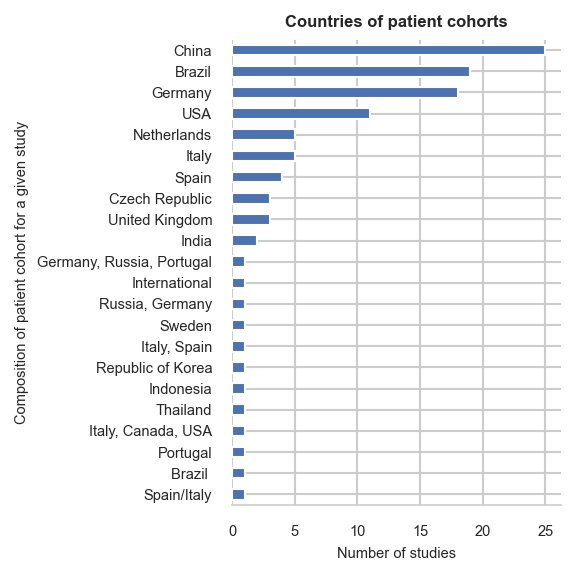

In [232]:
unique_pub_cohorts = deduplicated_df.drop_duplicates(['PubmedID', 'Country/region of selected patients'])
print(f"Set difference: {np.setdiff1d(unique_pub_cohorts['Country/region of selected patients'], unique_publications['Country/region of selected patients'])}")

country_counts = (
    unique_publications['Country/region of selected patients']
    .dropna()
    .value_counts()
    # .head(15)
)

plt.figure(figsize=(4,4))
country_counts.plot(kind='barh')
plt.xlabel("Number of studies")
plt.ylabel("Composition of patient cohort for a given study")
plt.title("Countries of patient cohorts", fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("figures/country_counts.pdf", bbox_inches="tight")
plt.savefig("figures/country_counts.png", dpi=600, bbox_inches="tight")
plt.show()

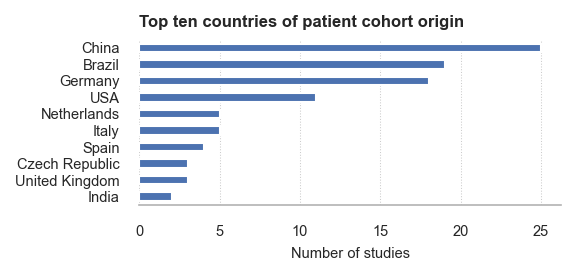

In [328]:
unique_pub_cohorts = deduplicated_df.drop_duplicates(['PubmedID', 'Country/region of selected patients'])

country_counts = (
    unique_publications['Country/region of selected patients']
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(4,2))
country_counts.plot(kind='barh')
plt.xlabel("Number of studies")
plt.ylabel("")
plt.title("Top ten countries of patient cohort origin", fontweight="bold", loc="left")
plt.gca().invert_yaxis()

ax = plt.gca()
ax.xaxis.grid(True, linestyle=":", linewidth=0.5, color="#cccccc")
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.spines["bottom"].set_color("0.7")
ax.tick_params(axis="both", labelsize=7)

plt.tight_layout()
plt.savefig("figures/country_counts_top10.pdf", bbox_inches="tight")
plt.savefig("figures/country_counts_top10.png", dpi=600, bbox_inches="tight")
plt.show()

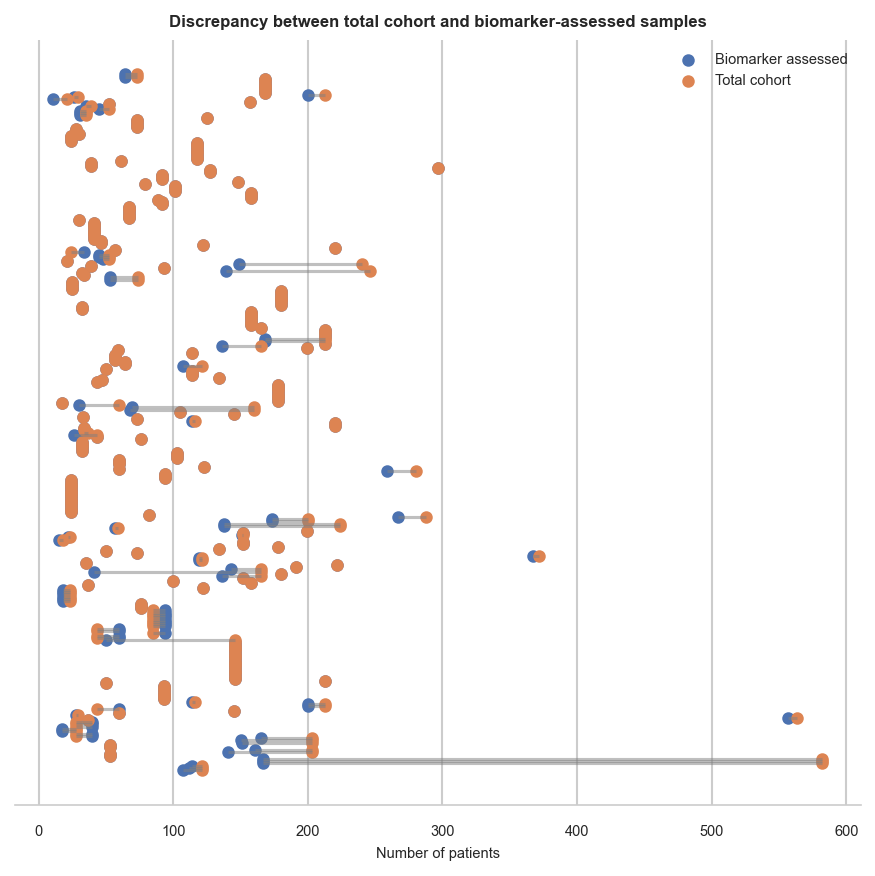

In [233]:
plot_df = (
    df.dropna(subset=["Sample_size_biomarker", "n_total"])
      .drop_duplicates(["PubmedID", "Biomarker name", "Sample_size_biomarker"])
      .copy()
)

plt.figure(figsize=(6, 6))

y = np.arange(len(plot_df))

plt.hlines(
    y=y,
    xmin=plot_df["Sample_size_biomarker"],
    xmax=plot_df["n_total"],
    color="grey",
    alpha=0.5
)

plt.scatter(
    plot_df["Sample_size_biomarker"],
    y,
    label="Biomarker assessed",
    s=25
)

plt.scatter(
    plot_df["n_total"],
    y,
    label="Total cohort",
    s=25
)

plt.xlabel("Number of patients")
plt.yticks([])
plt.legend(frameon=False)
plt.title("Discrepancy between total cohort and biomarker-assessed samples")
plt.tight_layout()
plt.show()

/var/folders/ml/ckydwkhn4zjbmx3s2k4ss7fckdkbsq/T/ipykernel_61107/3418106672.py:38: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig("figures/assessed_fraction.png", bbox_inches="tight", dpi=600)
/Users/niemeyfr/Library/Caches/pypoetry/virtualenvs/peca-sys-review-MqYnM_h9-py3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


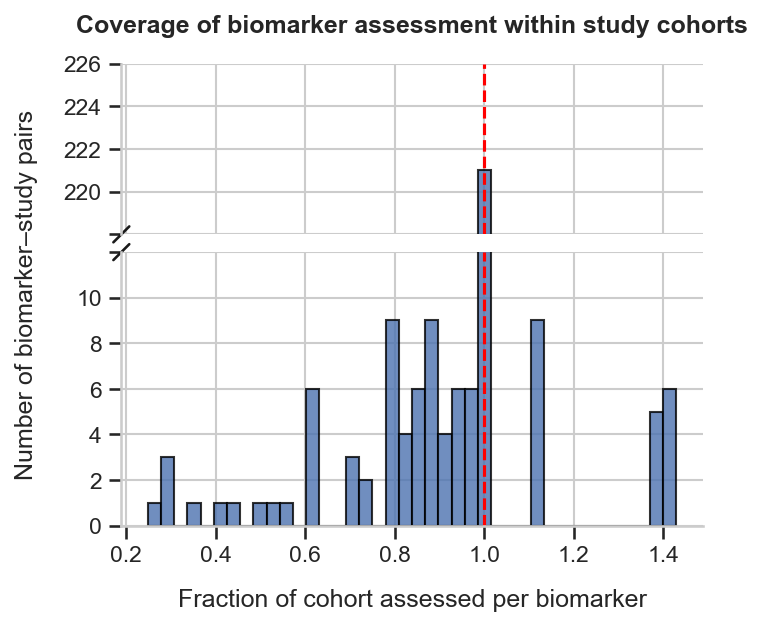

In [234]:
plot_df["assessed_fraction"] = (
    plot_df["Sample_size_biomarker"] / plot_df["n_total"]
)

sns.set_theme(style="whitegrid")

x = plot_df["assessed_fraction"].dropna().to_numpy()

fig = plt.figure(figsize=(5, 4), constrained_layout=True)
bax = brokenaxes(ylims=((2, 10), (220, 225)), hspace=0.08)

bax.hist(x, bins=40, edgecolor="black", alpha=0.8)
bax.axvline(1, linestyle="--", color="red")

top_ax = bax.axs[0]      # upper panel
bottom_ax = bax.axs[-1]  # lower panel

# remove bottom-most y tick label of top panel
yt = top_ax.get_yticks()
top_labels = [f"{t:g}" for t in yt]
if len(top_labels) > 0:
    top_labels[0] = ""
top_ax.set_yticks(yt)
top_ax.set_yticklabels(top_labels)

# remove top-most y tick label of bottom panel
yb = bottom_ax.get_yticks()
bottom_labels = [f"{t:g}" for t in yb]
if len(bottom_labels) > 0:
    bottom_labels[-1] = ""
bottom_ax.set_yticks(yb)
bottom_ax.set_yticklabels(bottom_labels)

bax.set_xlabel("Fraction of cohort assessed per biomarker", labelpad=30)
bax.set_ylabel("Number of biomarker–study pairs", labelpad=40)
bax.set_title("Coverage of biomarker assessment within study cohorts", fontweight="bold", pad=15)

plt.savefig("figures/assessed_fraction.png", bbox_inches="tight", dpi=600)
plt.show()

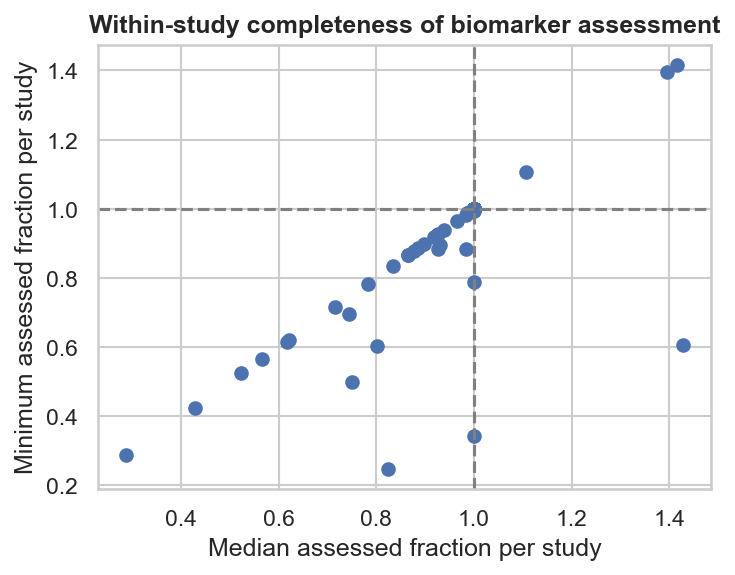

In [235]:
study_gap = (
    plot_df
    .groupby("PubmedID")
    .agg(
        min_fraction=("assessed_fraction", "min"),
        median_fraction=("assessed_fraction", "median")
    )
)

plt.figure(figsize=(5,4))
plt.scatter(study_gap["median_fraction"], study_gap["min_fraction"])
plt.axhline(1, linestyle="--", color="grey")
plt.axvline(1, linestyle="--", color="grey")

plt.xlabel("Median assessed fraction per study")
plt.ylabel("Minimum assessed fraction per study")
plt.title("Within-study completeness of biomarker assessment")
plt.tight_layout()
plt.show()

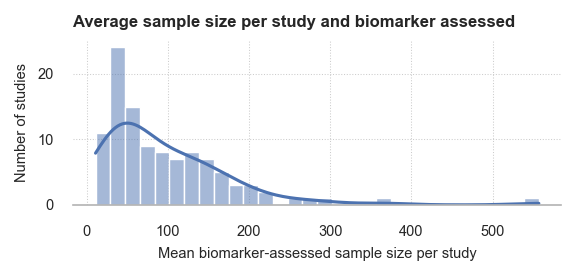

In [ ]:
study_assessed = (
    df
    .dropna(subset=["Sample_size_biomarker"])
    .groupby(["PubmedID", "Biomarker name"])["Sample_size_biomarker"]
    .agg(
        mean_assessed="mean",
        median_assessed="median",
    )
    .reset_index()
)

per_study = (
    study_assessed
    .groupby("PubmedID")
    .agg(
        mean_assessed=("mean_assessed", "mean"),
        median_assessed=("median_assessed", "median"),
        n_biomarkers=("Biomarker name", "nunique")
    )
    .reset_index()
)

plt.figure(figsize=(4,2))
sns.histplot(per_study["mean_assessed"], bins=30, kde=True)
plt.xlabel("Mean biomarker-assessed sample size per study")
plt.ylabel("Number of studies")
plt.title("Average sample size per study and biomarker assessed", fontweight="bold", loc="left")

ax = plt.gca()
ax.xaxis.grid(True, linestyle=":", linewidth=0.5, color="#cccccc")
ax.yaxis.grid(True, linestyle=":", linewidth=0.5, color="#cccccc")
ax.set_axisbelow(True)
ax.spines["bottom"].set_color("0.7")
ax.tick_params(axis="both", labelsize=7)

plt.tight_layout()
plt.savefig("figures/sample_size.pdf", bbox_inches="tight")
plt.savefig("figures/sample_size.png", dpi=600, bbox_inches="tight")
plt.show()

In [237]:
per_study = (
    study_assessed
    .groupby("PubmedID")["mean_assessed"]
    .mean()
)
print(f"Average cohort size per study: {per_study.mean()}")
print(f"Median cohort size per study: {per_study.median()}")

Average cohort size per study: 97.17984596746277
Median cohort size per study: 73.0


In [238]:
df2 = df.copy()

biomarker_table = (
    df2
    .dropna(subset=["PubmedID", "Biomarker name"])
    .drop_duplicates(["PubmedID", "Biomarker name"])
    .loc[:, [
        "PubmedID",
        "Biomarker name",
        "Sample_size_biomarker",
        "n_penile",
        "n_other",
        "n_total"
    ]]
    .sort_values(["PubmedID", "Biomarker name"])
    .reset_index(drop=True)
)

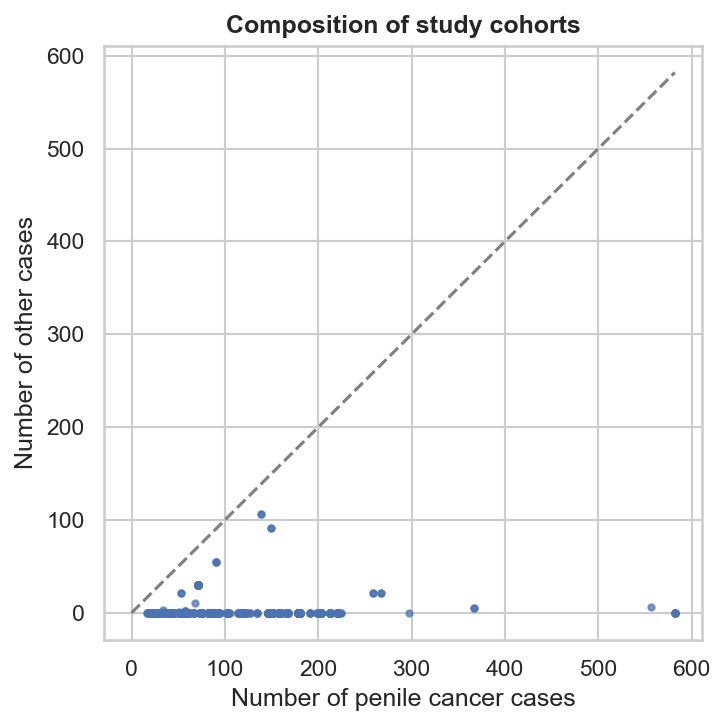

In [239]:
plt.figure(figsize=(5,5))

plt.scatter(
    df["n_penile"],
    df["n_other"],
    alpha=0.7,
    # s=.5,
    marker=".",
)

max_n = df[["n_penile", "n_other"]].max().max()

plt.plot([0, max_n], [0, max_n], linestyle="--", color="grey")

plt.xlabel("Number of penile cancer cases")
plt.ylabel("Number of other cases")
plt.title("Composition of study cohorts", fontweight="bold")

plt.tight_layout()
plt.show()

#### TMA vs whole-slide

In [240]:
df.loc[:, 'TMA'] = (
    df['TMA']
    .astype(str)
    .str.strip()
    .str.capitalize()
    .replace(['Nan', 'Na', 'N/a', ''], np.nan)
    .replace('Yes', 'TMA')
    .replace('No', 'Whole-slide')
)

tma_counts = df['TMA'].value_counts(dropna=False)
tma_counts

TMA
Whole-slide    422
TMA            256
NaN             18
Name: count, dtype: int64

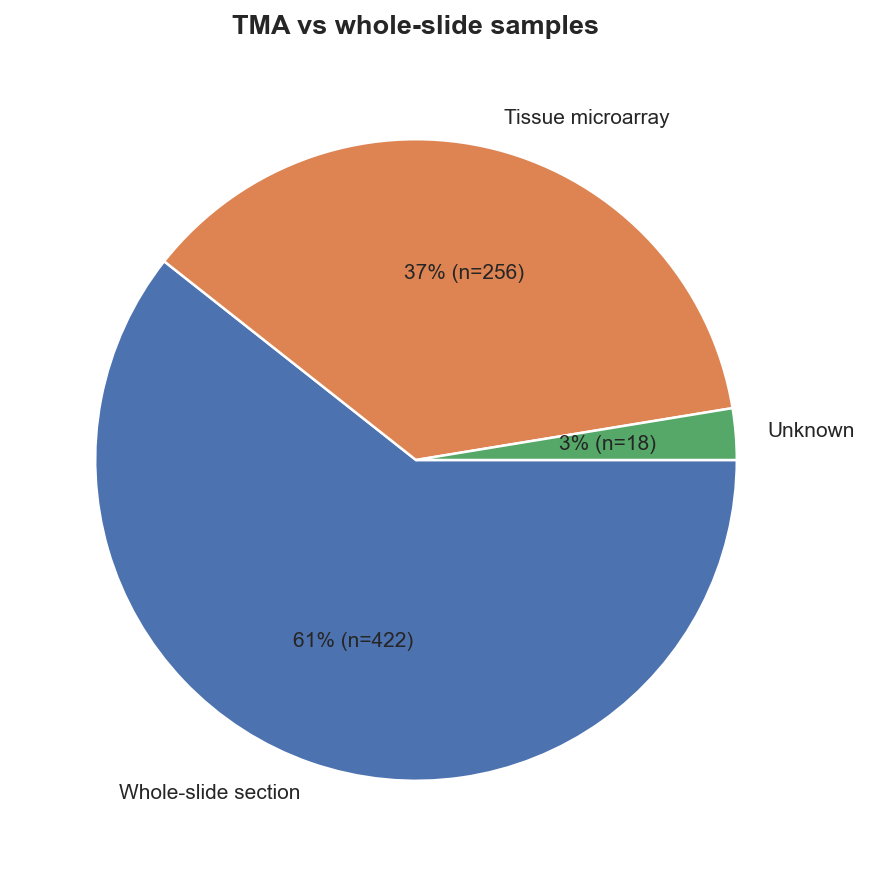

In [241]:
fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts, autotexts = ax.pie(
    tma_counts.values,
    labels=["Whole-slide section", "Tissue microarray", "Unknown"],
    autopct=lambda p: f"{p:.0f}% (n={int(round(p/100. * tma_counts.sum()))})",
    startangle=0,
    counterclock=False,
    wedgeprops=dict(edgecolor="white", linewidth=1.2),
    textprops=dict(fontsize=10)
)

# make percentage labels a bit clearer
for at in autotexts:
    at.set_fontsize(10)
    # at.set_weight("bold")

ax.set_title(
    "TMA vs whole-slide samples",
    fontsize=13,
    weight="bold",
    pad=12
)

ax.set_ylabel("")
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("figures/tma_samples.pdf", bbox_inches="tight")
plt.savefig("figures/tma_samples.png", dpi=600, bbox_inches="tight")
plt.show()

In [242]:
plot_df = df.copy()

plot_df = plot_df[plot_df["TMA"].isin(["TMA", "Whole-slide"])]

# Ensure numeric
plot_df["Sample_size_biomarker"] = pd.to_numeric(
    plot_df["Sample_size_biomarker"], errors="coerce"
)

plot_df = plot_df.dropna(subset=["Sample_size_biomarker"])
plot_df.head()

,Original_Index,Index,Title,Abstract,Authors,PubmedID,DOI,Year,Publication Types,Article Type,...,vi,P_value_pick,P_value_num,P_value_censored,P_value_threshold,Survival outcome standardized,Sample_size_biomarker,n_penile,n_other,n_total
0,8.0,8.0,Biomarkers of response to antibody-drug conjug...,We aimed to assess the expression of biomarker...,"Tekin B, Cheville JC, Lucien F, McCarthy M, Do...",40327767.0,https://dx.doi.org/10.1093/ajcp/aqaf022,2025.0,Journal Article,Journal Article,...,NaN,-,NaN,False,NaN,DSS,107.0,121.0,0.0,121.0
1,8.0,8.0,Biomarkers of response to antibody-drug conjug...,We aimed to assess the expression of biomarker...,"Tekin B, Cheville JC, Lucien F, McCarthy M, Do...",40327767.0,https://dx.doi.org/10.1093/ajcp/aqaf022,2025.0,Journal Article,Journal Article,...,NaN,-,NaN,False,NaN,DSS,112.0,121.0,0.0,121.0
2,8.0,8.0,Biomarkers of response to antibody-drug conjug...,We aimed to assess the expression of biomarker...,"Tekin B, Cheville JC, Lucien F, McCarthy M, Do...",40327767.0,https://dx.doi.org/10.1093/ajcp/aqaf022,2025.0,Journal Article,Journal Article,...,NaN,-,NaN,False,NaN,DSS,114.0,121.0,0.0,121.0
3,10.0,10.0,Neutrophil-to-lymphocyte ratio predicts a poor...,Chronic inflammation related to poor genital h...,"Tan X, Wang Y, Yu Y, Zheng R, Li J, Chen S, Xi...",40308599.0,https://dx.doi.org/10.3389/fimmu.2025.1568825,2025.0,Journal Article; Multicenter Study,Journal Article,...,0.10375035,0.028,0.028,False,NaN,PFS,167.0,582.0,0.0,582.0
4,10.0,10.0,Neutrophil-to-lymphocyte ratio predicts a poor...,Chronic inflammation related to poor genital h...,"Tan X, Wang Y, Yu Y, Zheng R, Li J, Chen S, Xi...",40308599.0,https://dx.doi.org/10.3389/fimmu.2025.1568825,2025.0,Journal Article; Multicenter Study,Journal Article,...,0.17277762,0.01,0.010,False,NaN,DSS,167.0,582.0,0.0,582.0


In [243]:
plot_df["Detection_simplified"] = (
    plot_df["Detection method"]
    .astype(str)
    .str.lower()
    .replace({
        "ihc": "IHC",
        "immunohistochemistry": "IHC"
    })
)

# Everything that is not IHC → "Other"
plot_df.loc[
    plot_df["Detection_simplified"] != "IHC",
    "Detection_simplified"
] = "Other"

/var/folders/ml/ckydwkhn4zjbmx3s2k4ss7fckdkbsq/T/ipykernel_61107/1553556309.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Tissue microarray", "Whole-slide section"], fontsize=7)


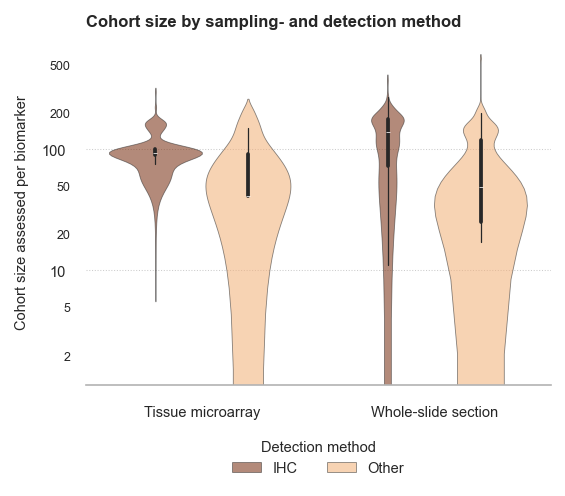

In [244]:
import matplotlib.ticker as ticker

# Style
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Arial", "Helvetica", "DejaVu Sans"],
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "axes.labelsize":   7,
    "axes.titlesize":   8,
    "axes.titleweight": "bold",
    "figure.dpi":       150,
})

# Palette
palette_det = {
    "IHC":   "#7F2704",   # dark burnt orange
    "Other": "#FDAE6B",   # light peach
}

# Figure
fig, ax = plt.subplots(figsize=(4, 3))

# Violin plot (grouped by TMA × Detection_simplified)
sns.violinplot(
    data=plot_df,
    x="TMA",
    y="Sample_size_biomarker",
    hue="Detection_simplified",
    hue_order=["IHC", "Other"],
    palette=palette_det,
    order=["TMA", "Whole-slide"],
    dodge=True,
    # cut=0,
    linewidth=0.4,
    saturation=0.85,
    alpha=0.55,
    ax=ax,
)

# Axes
ax.set_xlabel("")
ax.set_ylabel("Cohort size assessed per biomarker", fontsize=7, labelpad=6)
ax.set_xticklabels(["Tissue microarray", "Whole-slide section"], fontsize=7)
ax.set_title("Cohort size by sampling- and detection method",
             loc="left", pad=6, fontsize=8)

# Log y-axis if data is skewed (common for sample sizes) — remove if not needed
ax.set_yscale("log")

ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=10))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y):,}"))

# Add minor ticks at 2x and 5x positions (e.g. 20, 50, 200, 500, 2000 ...)
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10, subs=[2, 5], numticks=20))
ax.yaxis.set_minor_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y):,}"))

ax.yaxis.grid(True, linestyle=":", linewidth=0.5, color="#cccccc")
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("0.7")

ax.tick_params(axis="y", which="minor", labelsize=6)
ax.tick_params(axis="y", which="major", labelsize=7)

# Legend below plot
handles, labels = ax.get_legend_handles_labels()
# seaborn duplicates handles for strip+violin — keep first 2 only
ax.legend(
    handles[:2], labels[:2],
    title="Detection method",
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    fontsize=7,
    title_fontsize=7,
)

# Save
plt.savefig(
    "figures/sample_size_by_tissue_format.pdf",
    bbox_inches="tight"
)
plt.savefig(
    "figures/sample_size_by_tissue_format.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

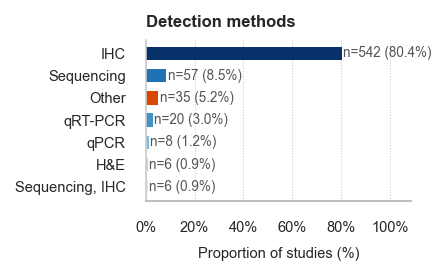

In [ ]:
import matplotlib.ticker as ticker

# Data prep
N = 6
bio_cat = (
    df["Detection method"]
    .dropna()
    .str.strip()
    .value_counts()
)
bio_cat_plot = pd.concat([
    bio_cat.iloc[:N],
    pd.Series({"Other": bio_cat.iloc[N:].sum()})
])

# Sort ascending so longest bar is at top
bio_cat_plot = bio_cat_plot.sort_values(ascending=True)
total = bio_cat_plot.sum()

# Colors: blues ramp for top methods, orange for Other
n = len(bio_cat_plot)
blue_ramp = ["#D0EAF8", "#A8D9EE", "#74C0E0", "#4292C6", "#2171B5", "#08306B"]
colors = []
blue_idx = 0
for label in bio_cat_plot.index:
    if label == "Other":
        colors.append("#D94801")   # orange — visually distinct
    else:
        colors.append(blue_ramp[blue_idx % len(blue_ramp)])
        blue_idx += 1

# Figure
fig, ax = plt.subplots(figsize=(3, 2))

bars = ax.barh(
    bio_cat_plot.index,
    bio_cat_plot.values / total * 100,
    color=colors,
    edgecolor="none",
    height=0.6,
)

# n and % labels at end of each bar
for bar, (label, val) in zip(bars, bio_cat_plot.items()):
    pct = val / total * 100
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"n={val:,} ({pct:.1f}%)",
        va="center", ha="left",
        fontsize=6.5, color="#555555",
    )

ax.set_xlabel("Proportion of studies (%)", fontsize=7, labelpad=6)
ax.set_title("Detection methods", loc="left", pad=6, fontsize=8)

# x-axis: percentage ticks
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlim(0, bio_cat_plot.max() / total * 100 * 1.35)  # room for labels

ax.xaxis.grid(True, linestyle=":", linewidth=0.5, color="#cccccc")
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.spines["bottom"].set_color("0.7")
ax.tick_params(axis="both", labelsize=7)

plt.tight_layout()
plt.savefig("figures/detection_methods.png", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig("figures/detection_methods.pdf", bbox_inches="tight")
plt.show()

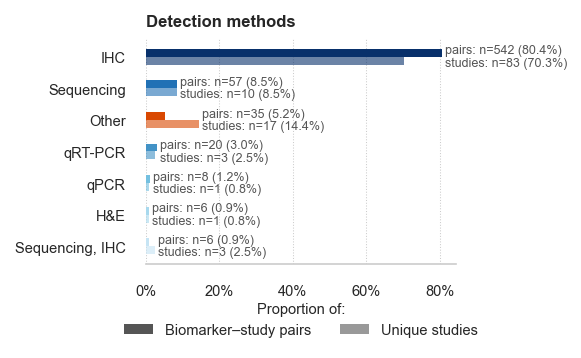

In [311]:
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

# Data prep
N = 6

# Biomarker-study pairs
pair_cat = (
    df["Detection method"]
    .dropna()
    .str.strip()
    .value_counts()
)
pair_cat_plot = pd.concat([
    pair_cat.iloc[:N],
    pd.Series({"Other": pair_cat.iloc[N:].sum()})
]).sort_values(ascending=True)   # sort by pairs for ordering

# Unique studies
study_cat = (
    df.drop_duplicates(["PubmedID", "Detection method"])["Detection method"]
    .dropna()
    .str.strip()
    .value_counts()
)
# Align to same categories as pair_cat_plot
other_studies = study_cat[~study_cat.index.isin(pair_cat.iloc[:N].index)].sum()
study_cat_plot = pd.concat([
    study_cat.reindex(pair_cat.iloc[:N].index, fill_value=0),
    pd.Series({"Other": other_studies})
]).reindex(pair_cat_plot.index)   # same order as pairs

pair_total  = pair_cat_plot.sum()
study_total = study_cat_plot.sum()

pair_pct  = pair_cat_plot  / pair_total  * 100
study_pct = study_cat_plot / study_total * 100

# Colors
blue_ramp = ["#C6E4F4", "#A8D9EE", "#74C0E0", "#4292C6", "#2171B5", "#08306B"]
colors = []
blue_idx = 0
for label in pair_cat_plot.index:
    if label == "Other":
        colors.append("#D94801")
    else:
        colors.append(blue_ramp[blue_idx % len(blue_ramp)])
        blue_idx += 1

# Figure
fig, ax = plt.subplots(figsize=(4, 2.8))

y = np.arange(len(pair_pct))
bar_h = 0.25

# Filled bars: biomarker–study pairs
bars_pairs = ax.barh(y + bar_h/2, pair_pct.values,
                     height=bar_h,
                     color=colors,
                     edgecolor="none",
                     zorder=2)

# Filled bars: unique studies
study_colors = [c + "99" for c in colors]
bars_studies = ax.barh(y - bar_h/2, study_pct.values,
                       height=bar_h,
                       color=study_colors,
                       edgecolor="none",
                       zorder=2)

# Annotations
for i, (pval, sval) in enumerate(zip(pair_pct.values, study_pct.values)):
    ax.text(max(pval, sval) + 0.8, i,
        f"pairs: n={pair_cat_plot.iloc[i]:,} ({pval:.1f}%)\n"
        f"studies: n={study_cat_plot.iloc[i]:,} ({sval:.1f}%)",
        va="center", ha="left", fontsize=6, color="#555555", linespacing=1)

# Legend
filled_patch  = mpatches.Patch(facecolor="#555555", edgecolor="none",
                                label="Biomarker–study pairs")
alpha_patch   = mpatches.Patch(facecolor="#55555599", edgecolor="none",
                                label="Unique studies")
ax.legend(
    handles=[filled_patch, alpha_patch],
    frameon=False,
    fontsize=7,
    loc="lower center",
    bbox_to_anchor=(.5, -0.38),
    ncol=2,
    title="Proportion of:",
    title_fontsize=7,
)

# title
ax.set_title("Detection methods", loc="left", pad=6, fontsize=8)

ax.grid(False)
ax.xaxis.grid(True, linestyle=":", linewidth=0.5, color="#cccccc")
ax.set_yticks(y)
ax.set_yticklabels(pair_cat_plot.index, fontsize=7)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
plt.savefig("figures/detection_methods.png",
            dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig("figures/detection_methods.pdf", bbox_inches="tight")
plt.show()

In [246]:
col = 'Presence of validation cohort/control group for the biomarker detection method'

df.loc[:, col] = (
    df[col]
    .astype(str)
    .str.strip()
    .str.capitalize()
    .replace(
        ['Nan', 'Na', 'N/a', 'None', '', '-', '—', '–'],
        np.nan
    )
)

validation_counts = (
    df[col]
    .fillna('Missing')
    .value_counts()
)

df[col].value_counts(dropna=False)

Presence of validation cohort/control group for the biomarker detection method
No     529
Yes    148
NaN     19
Name: count, dtype: int64

In [247]:
ratio = validation_counts['Yes'] / validation_counts.sum()
missing = validation_counts['Missing'] / validation_counts.sum()

print(f"Missing info: {missing:.1%}")
print(f"Validation cohort: {ratio:.1%}")
print(f"No validation cohort: {(1-ratio-missing):.1%}")

Missing info: 2.7%
Validation cohort: 21.3%
No validation cohort: 76.0%


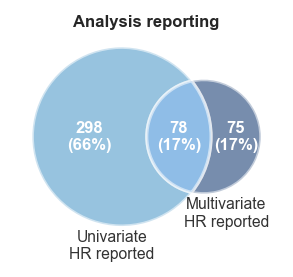

In [316]:
from matplotlib_venn import venn2

# Data
df_uni_multi = df.drop_duplicates(
    ['PubmedID', 'Biomarker name', 'HR_value_univariate', 'HR_value_multivariate']
)
has_uni   = df_uni_multi["HR_value_univariate"].notna()
has_multi = df_uni_multi["HR_value_multivariate"].notna()

uni_only   = (has_uni & ~has_multi).sum()
multi_only = (~has_uni & has_multi).sum()
both       = (has_uni & has_multi).sum()
total      = uni_only + multi_only + both

# Figure
fig, ax = plt.subplots(figsize=(2.5, 2))

v = venn2(
    subsets=(uni_only, multi_only, both),
    set_labels=("", ""),   # place labels manually below
    set_colors=("#4292C6", "#08306B"),
    alpha=0.55,
    ax=ax,
)

# Circle edge styling
for patch_id in ("10", "01", "11"):
    patch = v.get_patch_by_id(patch_id)
    if patch:
        patch.set_edgecolor("white")
        patch.set_linewidth(1.5)

# Count labels: n + % in white, bold
label_texts = {
    "10": f"{uni_only:,}\n({uni_only/total*100:.0f}%)",
    "01": f"{multi_only:,}\n({multi_only/total*100:.0f}%)",
    "11": f"{both:,}\n({both/total*100:.0f}%)",
}
for region_id, txt in label_texts.items():
    lbl = v.get_label_by_id(region_id)
    if lbl:
        lbl.set_text(txt)
        lbl.set_fontsize(8)
        lbl.set_fontweight("bold")
        lbl.set_color("white")

# Manual set labels below circles
for patch_id, text, ha in [("10", "Univariate\nHR reported", "right"),
                             ("01", "Multivariate\nHR reported", "left")]:
    patch = v.get_patch_by_id(patch_id)
    if patch is None:
        continue
    bb = patch.get_extents()                   # display coords
    ax_inv = ax.transData.inverted()
    cx, _ = ax_inv.transform(bb.max - (bb.max - bb.min) / 2)  # x centre
    _, y_bot = ax_inv.transform((0, bb.min[1]))                # bottom edge
    ax.text(cx, y_bot - 0.02, text,
            ha="center", va="top", fontsize=7.5,
            color="#333333", transform=ax.transData)

# Total annotation
# ax.text(0.5, -0.08, f"Total biomarker–study pairs: n={total:,}",
#         ha="center", va="top", fontsize=7, color="#888888",
#         transform=ax.transAxes)

# title
ax.set_title("Analysis reporting", loc="center", pad=-10,
             fontsize=8, fontweight="bold")

ax.axis("off")
plt.tight_layout()
plt.savefig("figures/univariate_vs_multivariate_venn.png",
            dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig("figures/univariate_vs_multivariate_venn.pdf",
            bbox_inches="tight")
plt.show()

/var/folders/ml/ckydwkhn4zjbmx3s2k4ss7fckdkbsq/T/ipykernel_61107/3532638287.py:45: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


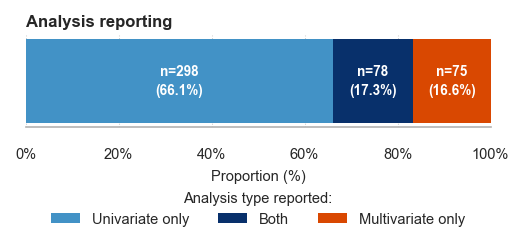

In [ ]:
fig, ax = plt.subplots(figsize=(4, 0.8))

segments = [
    (uni_only,   "#4292C6", "Univariate only"),
    (both,       "#08306B", "Both"),
    (multi_only, "#D94801", "Multivariate only"),
]

left = 0
for val, color, label in segments:
    pct = val / total * 100
    ax.barh(0, pct, left=left, height=0.5, color=color, edgecolor="none")
    # label inside bar if wide enough, otherwise skip
    if pct > 8:
        ax.text(left + pct / 2, 0,
                f"n={val:,}\n({pct:.1f}%)",
                ha="center", va="center",
                fontsize=6.5, color="white", fontweight="bold",
                linespacing=1.4)
    left += pct

ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel("Proportion (%)", fontsize=7, labelpad=4)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.xaxis.grid(True, linestyle=":", linewidth=0.5, color="#cccccc")
ax.grid(False)
ax.xaxis.grid(True, linestyle=":", linewidth=0.5, color="#cccccc")
ax.set_axisbelow(True)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("0.7")

# Legend below
handles = [mpatches.Patch(facecolor=c, edgecolor="none", label=l)
           for _, c, l in segments]
ax.legend(handles=handles, frameon=False, fontsize=7,
          loc="upper center", bbox_to_anchor=(0.5, -0.55),
          ncol=3, title="Analysis type reported:", title_fontsize=7)

ax.set_title("Analysis reporting", loc="left", pad=4, fontsize=8)

plt.tight_layout()
plt.savefig("figures/univariate_vs_multivariate_venn.png",
            dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig("figures/univariate_vs_multivariate_venn.pdf", bbox_inches="tight")
plt.show()

/var/folders/ml/ckydwkhn4zjbmx3s2k4ss7fckdkbsq/T/ipykernel_61107/1880174136.py:73: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(
/Users/niemeyfr/Library/Caches/pypoetry/virtualenvs/peca-sys-review-MqYnM_h9-py3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


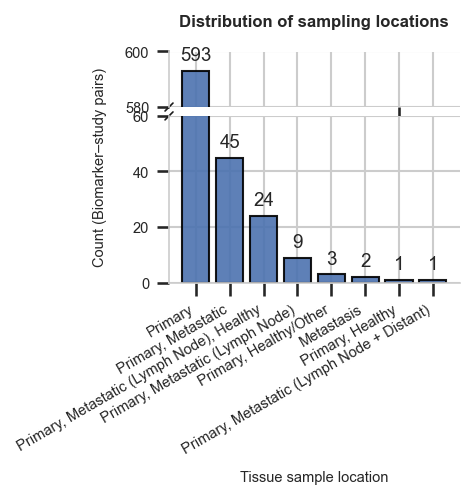

In [249]:
col = "Tissue sample location (Primary, Lymph Node/Metastasis)"

plot_df = df.copy()

# basic cleanup
plot_df[col] = (
    plot_df[col]
    .astype(str)
    .str.strip()
    .replace({"": np.nan, "nan": np.nan, "-": np.nan, "NA": np.nan, "N/A": np.nan})
)

# map common variants
plot_df[col] = plot_df[col].replace({
    "Primary tumor": "Primary",
    "Primary Tumor": "Primary",
    "Primary tumour": "Primary",
    "Lymph node": "Lymph Node",
    "Lymph nodes": "Lymph Node",
    "LN": "Lymph Node",
    "Metastasis": "Metastasis",
    "Metastatic": "Metastasis",
    "Lymph Node/Metastasis": "Lymph Node/Metastasis",
    "Lymph node/metastasis": "Lymph Node/Metastasis",
})

counts = plot_df[col].value_counts(dropna=True)

x = np.arange(len(counts))
labels = counts.index
values = counts.values

fig = plt.figure(figsize=(2.5, 2), constrained_layout=True)

# adjust y-lims to your data
bax = brokenaxes(
    ylims=((0, 60), (580, 600)),
    hspace=0.08
)

# draw bars
bars = bax.bar(
    x,
    values,
    edgecolor="black",
    alpha=0.9
)

for ax in bax.axs:
    y0, y1 = ax.get_ylim()
    for xi, yi in zip(x, values):
        if y0 <= yi <= y1:
            ax.annotate(
                f"{int(yi)}",
                xy=(xi, yi),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9
            )

# axis labels & title
bax.set_ylabel("Count (Biomarker–study pairs)", labelpad=30)
bax.set_xlabel("Tissue sample location", labelpad=90)
bax.set_title("Distribution of sampling locations", pad=12, fontweight="bold")

# x ticks
for ax in bax.axs:
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")

plt.savefig(
    "figures/primary_vs_mets.png",
    bbox_inches="tight",
    dpi=600
)
plt.show()

In [250]:
col = "Tissue sample location (Primary, Lymph Node/Metastasis)"

bias_df = (
    df.dropna(subset=["PubmedID", "Biomarker name", "Area of the biomarker", col])
      .drop_duplicates(["PubmedID", "Biomarker name", "Area of the biomarker", col])
      .copy()
)

# Optional: collapse locations to two main groups
bias_df[col] = bias_df[col].replace({
    "Lymph Node": "LN/Met",
    "Metastasis": "LN/Met",
    "Lymph Node/Metastasis": "LN/Met",
    "Primary ": "Primary",
    "Primary, Metastatic (Lymph Node + Distant)": "Primary, Metastatic",
    "Primary, Metastatic (Lymph Node)": "Primary, Metastatic",
    "Primary, Metastatic (Lymph Node), Healthy": "Primary, Metastatic, Healthy",
})

bias_df = bias_df[bias_df[col].isin(["Primary", "Primary, Metastatic", "Primary, Metastatic, Healthy"])].copy()

bio_loc = (
    bias_df
    .groupby(["Biomarker name", col])["PubmedID"]
    .nunique()
    .unstack(fill_value=0)
)

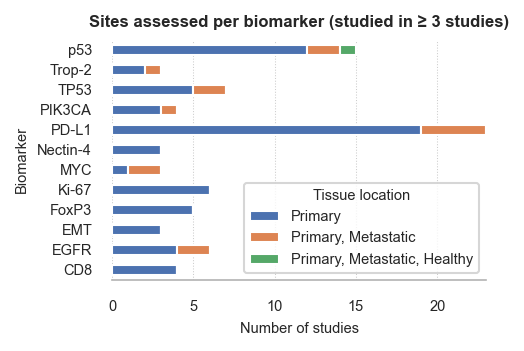

In [330]:
min_studies = 3

bio_loc = (
    bias_df
    .groupby(["Biomarker name", col])["PubmedID"]
    .nunique()
    .unstack(fill_value=0)
)

bio_loc = bio_loc[bio_loc.sum(axis=1) >= min_studies]

plt.figure(figsize=(3.5, 2.5))

bio_loc.plot(
    kind="barh",
    stacked=True,
    ax=plt.gca()
)

plt.xlabel("Number of studies")
plt.ylabel("Biomarker")
plt.title(f"Sites assessed per biomarker (studied in ≥ {min_studies} studies)", fontweight="bold")
plt.legend(title="Tissue location", frameon=True, fontsize=7, title_fontsize=7)

ax = plt.gca()
ax.xaxis.grid(True, linestyle=":", linewidth=0.5, color="#cccccc")
ax.yaxis.grid(False)
ax.set_axisbelow(True)
ax.spines["bottom"].set_color("0.7")
ax.tick_params(axis="both", labelsize=7)

plt.tight_layout()
plt.savefig("figures/tissue_location_bias.pdf", bbox_inches="tight")
plt.savefig("figures/tissue_location_bias.png", bbox_inches="tight", dpi=600)
plt.show()